In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.filters import frangi, threshold_otsu, apply_hysteresis_threshold
from skimage.morphology import closing, opening, disk, remove_small_objects
from skimage.exposure import equalize_adapthist
from sklearn.metrics import jaccard_score, f1_score, accuracy_score, confusion_matrix

DATA_DIR = Path.cwd() / "data"
ORIGINAL_DIR = DATA_DIR / "original"
LABELS_DIR = DATA_DIR / "labels"


In [2]:
def split_channels(image: np.ndarray):
    """Return R, G, B channels from RGB image."""
    return image[:, :, 0], image[:, :, 1], image[:, :, 2]

In [3]:
def load_image(path: Path) -> np.ndarray:
    return np.array(Image.open(path))


def load_label(path: Path) -> np.ndarray:
    lbl = np.array(Image.open(path))
    return (lbl > 0).astype(np.uint8)

def display_images(*images, titles=None, cmap="gray", figsize_per_image=(4, 4)):
    """Display 1..N images in a horizontal row."""
    n = len(images)
    if n == 0:
        print("No images to display.")
        return
    if titles is None:
        titles = [f"Image {i + 1}" for i in range(n)]
    elif len(titles) != n:
        raise ValueError(f"{n} images but {len(titles)} titles")

    fig, axes = plt.subplots(1, n, figsize=(figsize_per_image[0] * n, figsize_per_image[1]))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [4]:
def evaluate(pred: np.ndarray, gold: np.ndarray) -> dict:
    """Compute evaluation metrics between prediction and gold standard."""
    p_flat = pred.ravel()
    g_flat = gold.ravel()

    return {
        "accuracy": accuracy_score(g_flat, p_flat),
        "f1": f1_score(g_flat, p_flat, zero_division=0),
        "iou": jaccard_score(g_flat, p_flat, zero_division=0),
        "tn": int(confusion_matrix(g_flat, p_flat).ravel()[0]),
        "fp": int(confusion_matrix(g_flat, p_flat).ravel()[1]),
        "fn": int(confusion_matrix(g_flat, p_flat).ravel()[2]),
        "tp": int(confusion_matrix(g_flat, p_flat).ravel()[3]),
    }

In [5]:
import cv2

def create_foreground_mask(image: np.ndarray, threshold: int = 30) -> np.ndarray:
    """Binary mask: True where sum(RGB) > threshold (eye region)."""
    return np.sum(image, axis=2) > threshold


def apply_mask(data: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Zero out pixels outside mask."""
    return data * mask


def create_retinal_mask_convex_hull(image_rgb: np.ndarray) -> np.ndarray:
    """
    Advanced retinal mask using convex hull + morphological closing.
    Best for images with irregular dark corners. Prevents edge artifacts in Frangi.
    """
    red = image_rgb[:, :, 0]
    red_blur = cv2.medianBlur(red, 9)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(
        red_blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51,  # block size
        15   # constant
    )

    # Find largest contour (retina circular area)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.ones_like(binary, dtype=bool)

    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    # Draw and close hull
    mask = np.zeros_like(binary, dtype=np.uint8)
    cv2.drawContours(mask, [hull], -1, 255, -1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Erode slightly to clean edge artifacts and prevent boundary false positives
    mask = cv2.erode(mask, kernel, iterations=1)

    return mask > 0


In [6]:
from skimage.filters import gaussian
import cv2

def apply_clahe(
    green: np.ndarray,
    mask: np.ndarray,
    clip_limit: float = 0.015,
    nbins: int = 256,
    kernel = 128
) -> np.ndarray:
    """Apply CLAHE to green channel within foreground mask."""
    normalized = green.astype(float) / 255.0
    normalized[~mask] = 0
    enhanced = equalize_adapthist(normalized, kernel_size=kernel, clip_limit=clip_limit, nbins=nbins)
    enhanced[~mask] = 0
    return enhanced


def preprocess_image(image, mask, *, clip_limit = 0.015, nbins = 256, kernel = 128, gauss: tuple[int, int] = (51, 51)):
    if isinstance(image, (str, Path)):
        img = np.array(Image.open(image)).astype(np.uint8)
    else:
        img = image.astype(np.uint8)

    # 1. First median blur to reduce noise
    img = cv2.medianBlur(img, 5)

    # 2. Subtract local background to flatten background illumination
    bg_map = cv2.GaussianBlur(img, gauss, 0)
    flat_bg = cv2.subtract(bg_map, img)
    flat_bg = np.clip(flat_bg, 0, 255).astype(np.uint8)

    # 3. Second median blur to smooth background noise in the subtracted image
    flat_bg = cv2.medianBlur(flat_bg, 5)
    
    # 4. Apply CLAHE inside the mask
    clahe = apply_clahe(flat_bg, mask=mask, clip_limit=clip_limit, nbins=nbins, kernel=kernel)
    return clahe


In [7]:
def frangi_vesselness(
    image: np.ndarray,
    sigmas: tuple = (1, 2, 3),
    alpha: float = 0.5,
    beta: float = 0.5,
    gamma: float = None,  # Fix: Default gamma to None so skimage automatically computes it
    scale_step=2,
    black_ridges: bool = True,
) -> np.ndarray:
    """Apply Frangi vesselness filter. Returns vessel probability map."""
    return frangi(image, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=black_ridges, scale_step=scale_step)


Evaluation Metrics for im0001.ppm:
Accuracy: 0.9253
F1-Score: 0.6064
IoU (Jaccard): 0.4352


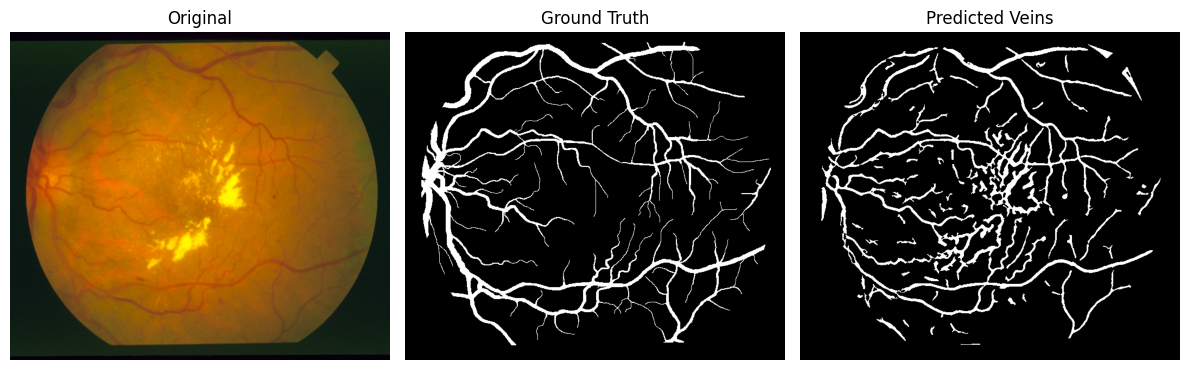

In [8]:
def extract_veins(
    image: np.ndarray,
    sigmas: tuple = (0.5, 1, 1.5, 2, 2.5, 3),
    clip_limit: float = 0.015,
    alpha: float = 0.5,
    beta: float = 0.5,
    gamma: float = None,  # Default gamma to None
) -> np.ndarray:
    """Extract veins from eye image. Returns binary vein mask."""
    _, green, _ = split_channels(image)
    
    # 1. Use an eroded retinal mask (erode size 20 inside) to prevent edge artifacts in the Frangi filter
    fg_mask = create_retinal_mask_convex_hull(image)

    # 2. Preprocess the green channel
    enhanced = preprocess_image(green, fg_mask, clip_limit=clip_limit, kernel=128, gauss=(51, 51))
    
    # 3. Apply Frangi vesselness filter (black_ridges=False because vessels are bright in flat_bg)
    vesselness = frangi_vesselness(enhanced, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma, black_ridges=False, scale_step=None)
    vesselness_masked = apply_mask(vesselness, fg_mask)

    # 4. Threshold using the tuned scaled Otsu multiplier (0.32)
    thresh = threshold_otsu(vesselness_masked[fg_mask])
    binary = vesselness_masked > thresh * 0.32

    # 5. Clean up mask using morphological operations
    binary = closing(binary, disk(1))
    binary = remove_small_objects(binary, min_size=40)

    return binary.astype(np.uint8)


# Load image and labels correctly
img = load_image(ORIGINAL_DIR / "im0001.ppm")
orig = load_label(LABELS_DIR / "im0001.vk.ppm")

# Extract veins
r = extract_veins(img)

# Evaluate metrics
metrics = evaluate(r, orig)
print("Evaluation Metrics for im0001.ppm:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1-Score: {metrics['f1']:.4f}")
print(f"IoU (Jaccard): {metrics['iou']:.4f}")

# Display results
display_images(img, orig, r, titles=["Original", "Ground Truth", "Predicted Veins"])
